<a href="https://colab.research.google.com/github/RayCharles8/ML-Project/blob/main/Tabular_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Mount Colab to Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

BASE_DIR  = '/content/drive/MyDrive/IML Project'
DATA_PATH = os.path.join(BASE_DIR, 'Dataset.csv')

print("Dataset path:", DATA_PATH)

Dataset path: /content/drive/MyDrive/IML Project/Dataset.csv


Required Libraries

In [36]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

from xgboost import XGBClassifier
import shap

np.random.seed(42)

!pip install pysr

from pysr import PySRRegressor
import sympy as sp


Load Data

In [4]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

print("\nLabel distribution:")
print(df['label'].value_counts())

print("\nClass balance:")
print(df['label'].value_counts(normalize=True).round(3))

# Remove duplicates
df = df.drop_duplicates()

print("\nAfter removing duplicates:", df.shape)

Shape: (9668, 17)

Columns:
 ['mp_material_id', 'mp_formula', 'spacegroup', 'spacegroup_number', 'number of atoms', 'Band Gap', 'a', 'b', 'c', 'alpha', 'beta', 'gamma', 'Z', 'electronegativity', 'Topological Label', 'label', 'cif']

Label distribution:
label
0    5198
1    4470
Name: count, dtype: int64

Class balance:
label
0    0.538
1    0.462
Name: proportion, dtype: float64

After removing duplicates: (9668, 17)


###Feature Engineering

In [5]:
FEATURES = [
    'spacegroup_number',
    'spacegroup',
    'number of atoms',
    'Band Gap',
    'a', 'b', 'c',
    'alpha', 'beta', 'gamma',
    'Z',
    'electronegativity'
]

TARGET = 'label'

df_model = df[FEATURES + [TARGET]].dropna().copy()

###Encode categorical features

In [6]:
le = LabelEncoder()
df_model['spacegroup'] = le.fit_transform(df_model['spacegroup'].astype(str))

X = df_model[FEATURES]
y = df_model[TARGET]

print("Feature matrix:", X.shape)
print("Target:", y.shape)

Feature matrix: (9668, 12)
Target: (9668,)


###Stratified Split of Data (70% 15% 15%)

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

for name, yy in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"{name}: {len(yy)} samples | TI ratio: {yy.mean():.3f}")

Train: 6767 samples | TI ratio: 0.462
Val: 1450 samples | TI ratio: 0.462
Test: 1451 samples | TI ratio: 0.462


####Random Forest Training

In [8]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=3,
    min_samples_split=8,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=3, min_samples_split=8,
                       n_estimators=500, n_jobs=-1, random_state=42)

In [9]:

# Evaluation

def evaluate_model(model, X_data, y_true, name="Set"):
    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:,1]


    print(f"\n{name} Performance")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print(classification_report(y_true, y_pred))

    return y_prob

In [10]:
print("\nRANDOM FOREST")

rf_train_prob = evaluate_model(rf, X_train, y_train, "Train")
rf_val_prob   = evaluate_model(rf, X_val, y_val, "Validation")
rf_test_prob  = evaluate_model(rf, X_test, y_test, "Test")


RANDOM FOREST

Train Performance
Accuracy: 0.9358652283138762
F1-score: 0.9317180616740088
ROC-AUC: 0.9903217888798875
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      3638
           1       0.92      0.95      0.93      3129

    accuracy                           0.94      6767
   macro avg       0.94      0.94      0.94      6767
weighted avg       0.94      0.94      0.94      6767


Validation Performance
Accuracy: 0.8510344827586207
F1-score: 0.8409425625920471
ROC-AUC: 0.9248737083811711
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       780
           1       0.83      0.85      0.84       670

    accuracy                           0.85      1450
   macro avg       0.85      0.85      0.85      1450
weighted avg       0.85      0.85      0.85      1450


Test Performance
Accuracy: 0.870434183321847
F1-score: 0.8607407407407407
ROC-AUC: 0.9368527647216172
             

RF Confunsion Matrix

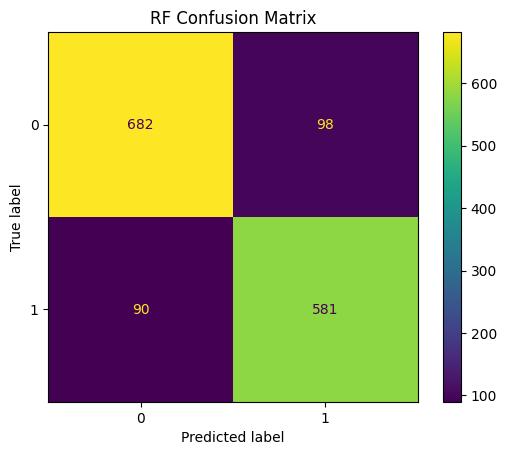

In [11]:
cm = confusion_matrix(y_test, rf.predict(X_test))
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("RF Confusion Matrix")
plt.show()

###XGBoost Training

In [12]:
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=5,
    gamma=0.2,
    reg_alpha=0.1,
    reg_lambda=1.5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.2,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1,
              num_parallel_tree=None, ...)

In [13]:
print("\nXGBoost")

xgb_train_prob = evaluate_model(xgb_model, X_train, y_train, "Train")
xgb_val_prob   = evaluate_model(xgb_model, X_val, y_val, "Validation")
xgb_test_prob  = evaluate_model(xgb_model, X_test, y_test, "Test")


XGBoost

Train Performance
Accuracy: 0.900990099009901
F1-score: 0.8948524795982423
ROC-AUC: 0.9666908160742814
              precision    recall  f1-score   support

           0       0.92      0.89      0.91      3638
           1       0.88      0.91      0.89      3129

    accuracy                           0.90      6767
   macro avg       0.90      0.90      0.90      6767
weighted avg       0.90      0.90      0.90      6767


Validation Performance
Accuracy: 0.8517241379310345
F1-score: 0.8427212874908558
ROC-AUC: 0.9264016456180635
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       780
           1       0.83      0.86      0.84       670

    accuracy                           0.85      1450
   macro avg       0.85      0.85      0.85      1450
weighted avg       0.85      0.85      0.85      1450


Test Performance
Accuracy: 0.8738800827015851
F1-score: 0.8641425389755011
ROC-AUC: 0.9373399824219495
              preci

XGB Confunsion Matrix

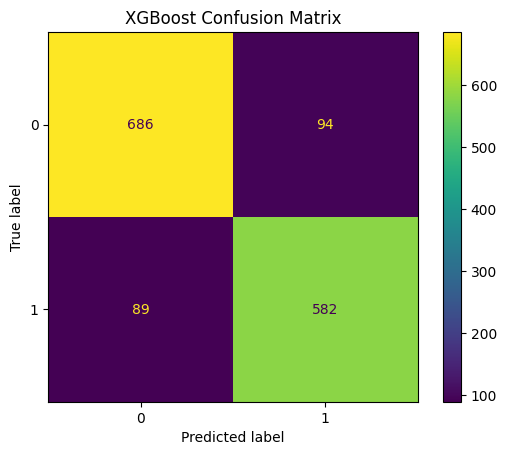

In [14]:
cm = confusion_matrix(y_test, xgb_model.predict(X_test))
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

###RF & XGB ROC CURVES

<Figure size 700x600 with 0 Axes>

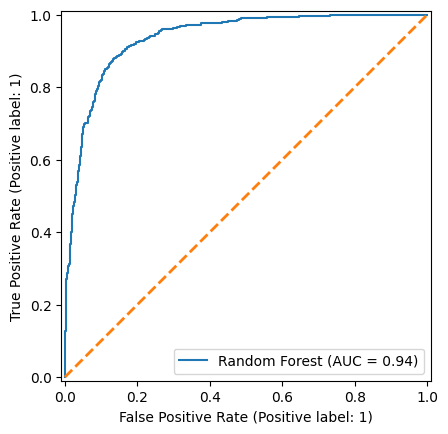

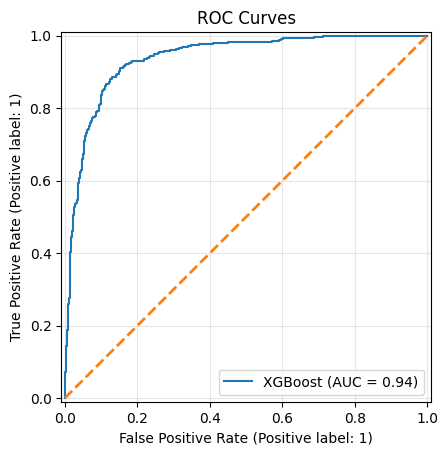

In [15]:
# RF & XGB ROC CURVES
plt.figure(figsize=(7,6))

# Random Forest ROC
RocCurveDisplay.from_predictions(
    y_test,
    rf_test_prob,
    name="Random Forest"
)
# Diagonal random-classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2
)

# XGBoost ROC
RocCurveDisplay.from_predictions(
    y_test,
    xgb_test_prob,
    name="XGBoost"
)

# Diagonal random-classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2
)

plt.title("ROC Curves")
plt.grid(alpha=0.3)

plt.show()

# Scatter PLOTS

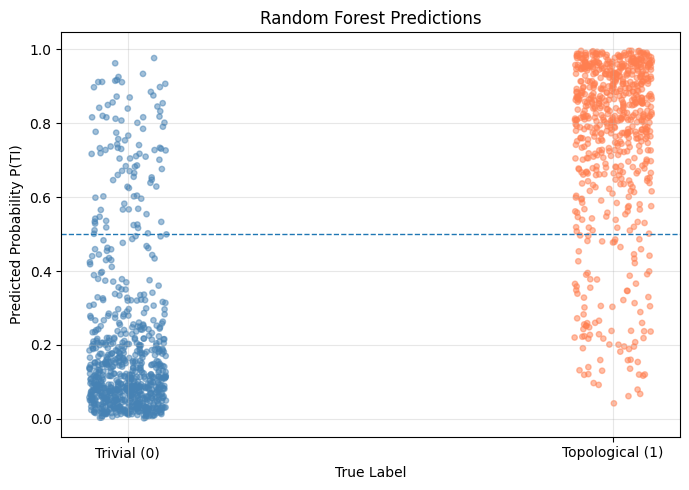

In [16]:
# RF SCATTER PLOT

plt.figure(figsize=(7,5))

# jitter improves visibility
jitter_rf = np.random.uniform(-0.08, 0.08, size=len(y_test))

colors_rf = [
    'steelblue' if l == 0 else 'coral'
    for l in y_test
]

plt.scatter(
    y_test + jitter_rf,
    rf_test_prob,
    c=colors_rf,
    alpha=0.5,
    s=15
)

# decision threshold
plt.axhline(
    0.5,
    linestyle='--',
    linewidth=1
)

plt.xticks(
    [0, 1],
    ['Trivial (0)', 'Topological (1)']
)

plt.xlabel("True Label")
plt.ylabel("Predicted Probability P(TI)")
plt.title("Random Forest Predictions")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

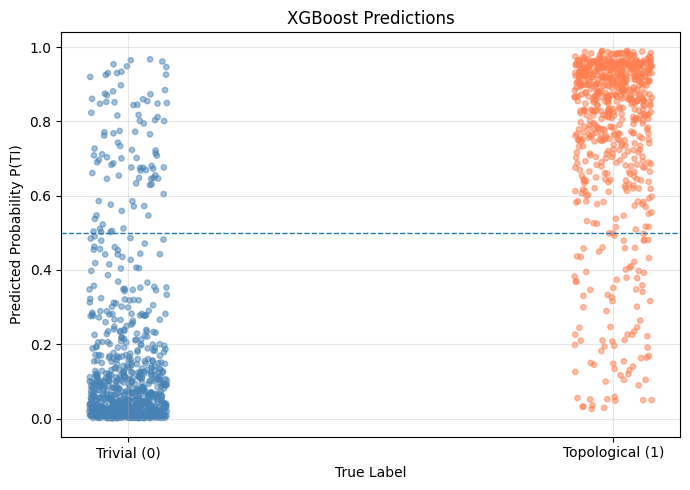

In [17]:
# XGBOOST SCATTER PLOT

plt.figure(figsize=(7,5))

jitter_xgb = np.random.uniform(-0.08, 0.08, size=len(y_test))

colors_xgb = [
    'steelblue' if l == 0 else 'coral'
    for l in y_test
]

plt.scatter(
    y_test + jitter_xgb,
    xgb_test_prob,
    c=colors_xgb,
    alpha=0.5,
    s=15
)

plt.axhline(
    0.5,
    linestyle='--',
    linewidth=1
)

plt.xticks(
    [0, 1],
    ['Trivial (0)', 'Topological (1)']
)

plt.xlabel("True Label")
plt.ylabel("Predicted Probability P(TI)")
plt.title("XGBoost Predictions")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

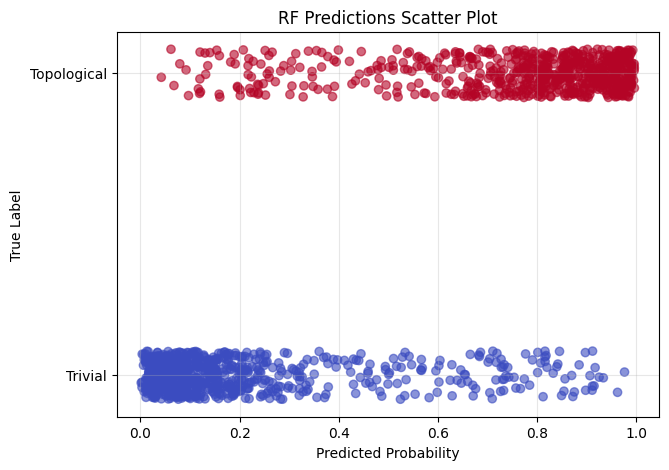

In [18]:
# RF PROBABILITY SCATTER

plt.figure(figsize=(7,5))

jitter = np.random.uniform(-0.08, 0.08, size=len(y_test))

plt.scatter(
    rf_test_prob,
    y_test + jitter,
    c=y_test,
    cmap='coolwarm',
    alpha=0.6
)

plt.xlabel("Predicted Probability")
plt.ylabel("True Label")

plt.title("RF Predictions Scatter Plot")

plt.yticks(
    [0,1],
    ["Trivial", "Topological"]
)

plt.grid(alpha=0.3)

plt.show()

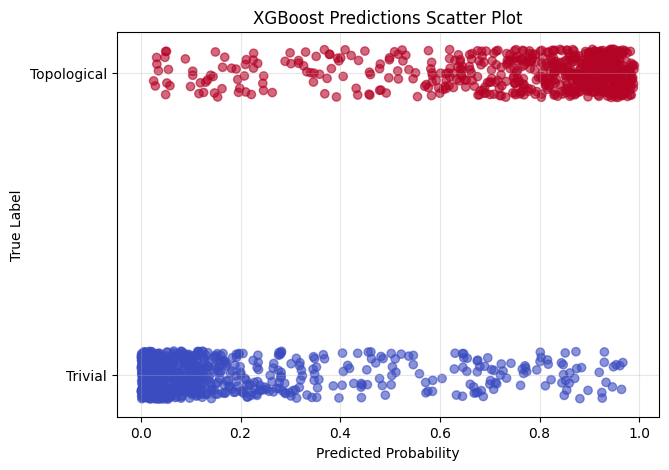

In [19]:
# XGB PROBABILITY SCATTER

plt.figure(figsize=(7,5))

jitter = np.random.uniform(-0.08, 0.08, size=len(y_test))

plt.scatter(
    xgb_test_prob,
    y_test + jitter,
    c=y_test,
    cmap='coolwarm',
    alpha=0.6
)

plt.xlabel("Predicted Probability")
plt.ylabel("True Label")

plt.title("XGBoost Predictions Scatter Plot")

plt.yticks(
    [0,1],
    ["Trivial", "Topological"]
)

plt.grid(alpha=0.3)

plt.show()

###SHAP INTERPRETABILITY

In [20]:
#RF
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test)

In [21]:
#XGB
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

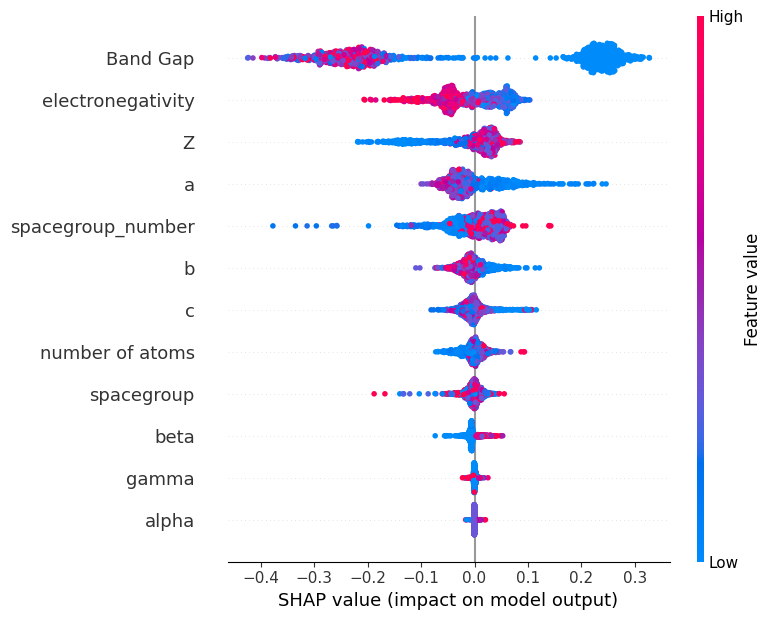

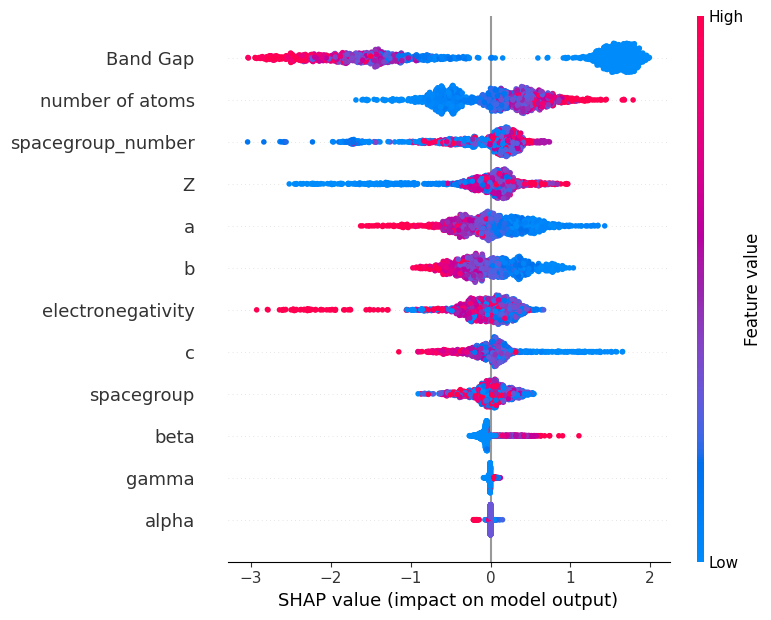

In [22]:
#Beeswarm Plot
shap.summary_plot(shap_values_rf[:, :, 1], X_test)
shap.summary_plot(shap_values_xgb, X_test)

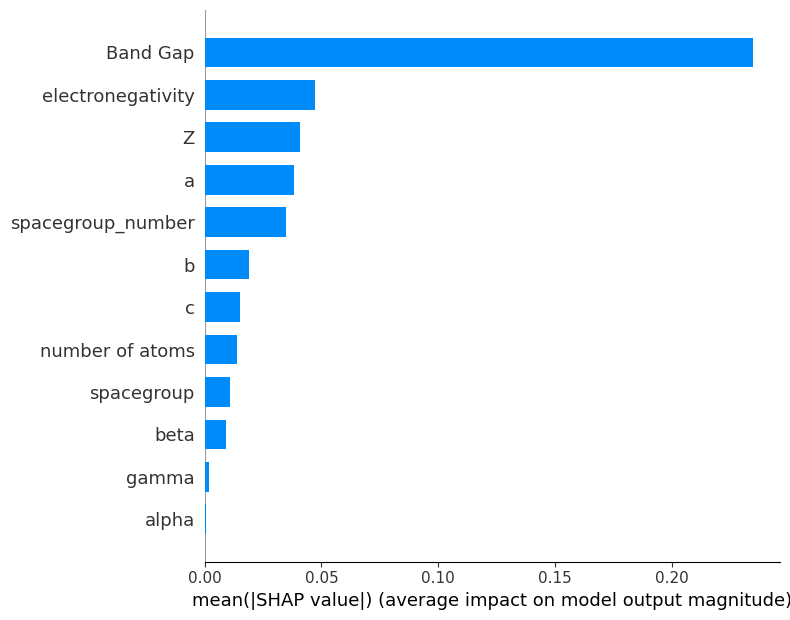

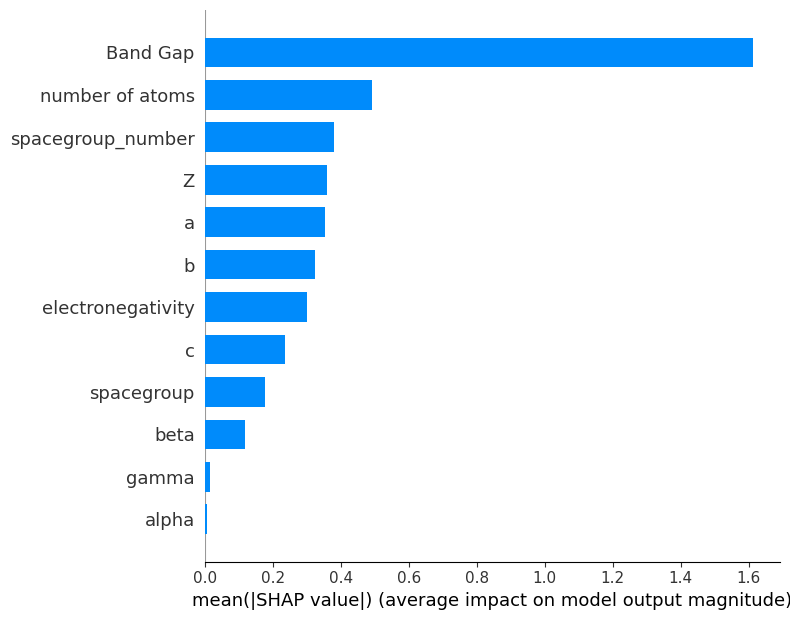

In [23]:
#Bar PLot
shap.summary_plot(shap_values_rf[:, :, 1], X_test, plot_type="bar")
shap.summary_plot(shap_values_xgb, X_test, plot_type="bar")

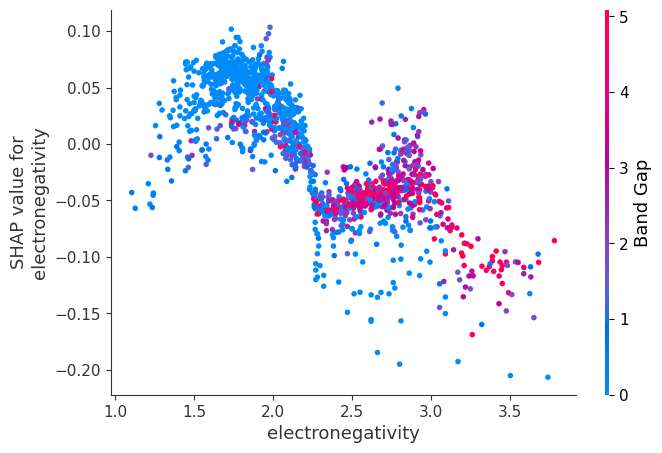

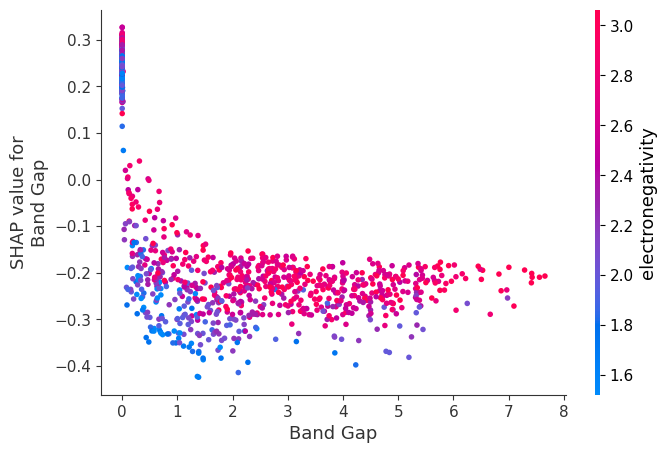

In [24]:
#Dependance plots
import numpy as np

# Calculate feature importance for the positive class (index 1) across all samples
rf_importance = np.abs(shap_values_rf[:, :, 1]).mean(axis=0)
top_features = np.argsort(rf_importance)[-2:]

for i in top_features:
    # Use SHAP values for the positive class (index 1) for all samples
    shap.dependence_plot(X.columns[i], shap_values_rf[:, :, 1], X_test)

<Figure size 600x500 with 0 Axes>

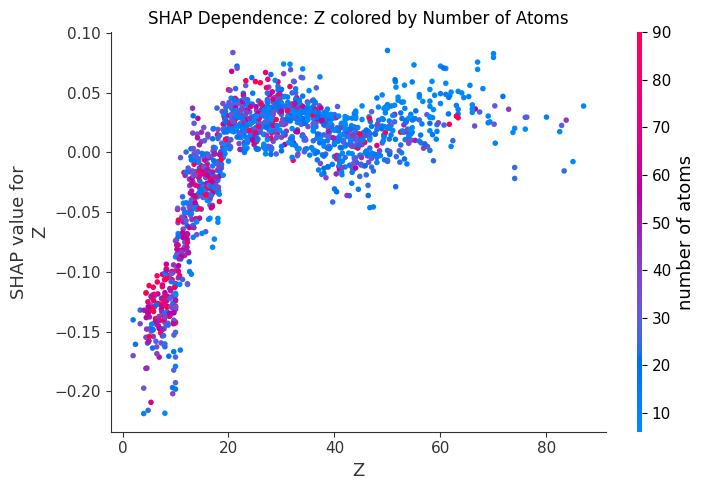

In [25]:

plt.figure(figsize=(6,5))

shap.dependence_plot(
    'Z',
    shap_values_rf[:, :, 1],
    X_test,
    interaction_index='number of atoms',
    show=False
)

plt.title("SHAP Dependence: Z colored by Number of Atoms")
plt.tight_layout()
plt.show()

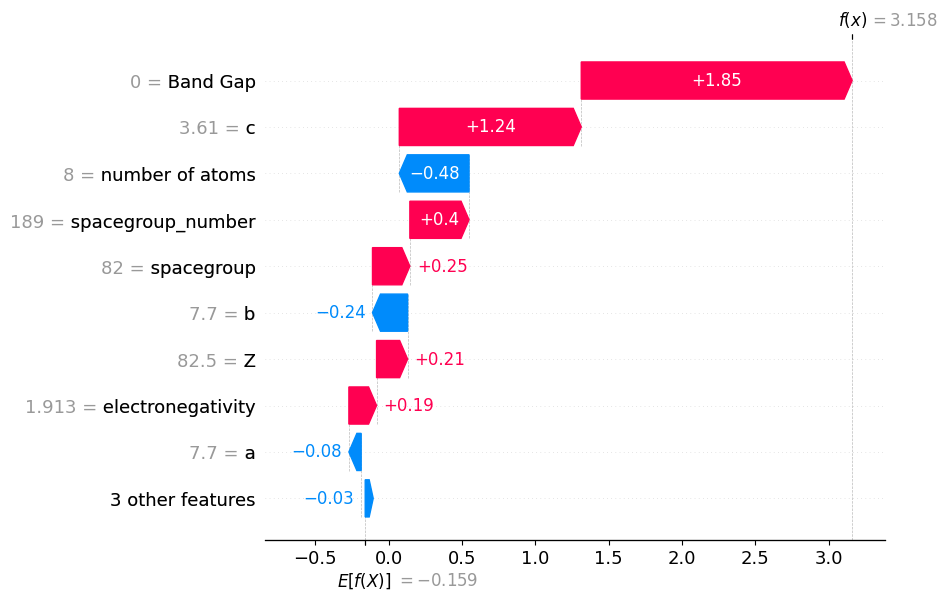

In [26]:
#Waterfall PLot
shap.plots.waterfall(shap.Explanation(
    values=shap_values_xgb[0],
    base_values=explainer_xgb.expected_value,
    data=X_test.iloc[0]
))

In [27]:
#Force PLot
shap.initjs()
shap.force_plot(
    explainer_xgb.expected_value,
    shap_values_xgb[0],
    X_test.iloc[0]
)

<Figure size 600x500 with 0 Axes>

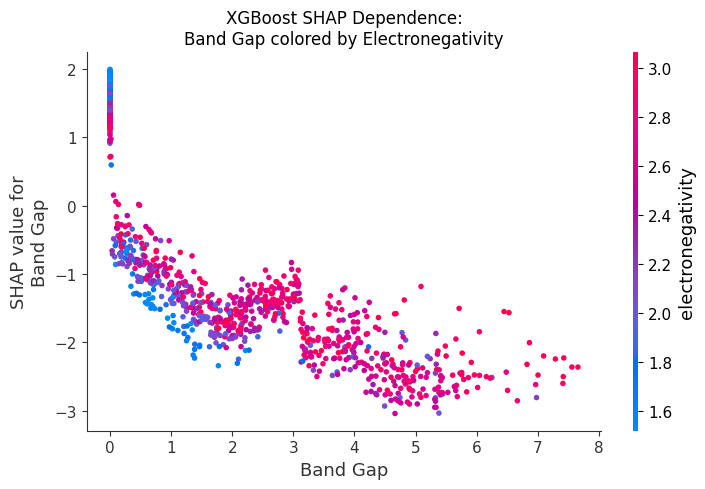

In [28]:

# XGBOOST SHAP DEPENDENCE
# Band Gap vs SHAP(Band Gap)
# colored by Electronegativity
plt.figure(figsize=(6,5))

shap.dependence_plot(
    "Band Gap",
    shap_values_xgb,
    X_test,
    interaction_index="electronegativity",
    show=False
)

plt.title(
    "XGBoost SHAP Dependence:\nBand Gap colored by Electronegativity"
)

plt.tight_layout()

plt.show()

<Figure size 600x500 with 0 Axes>

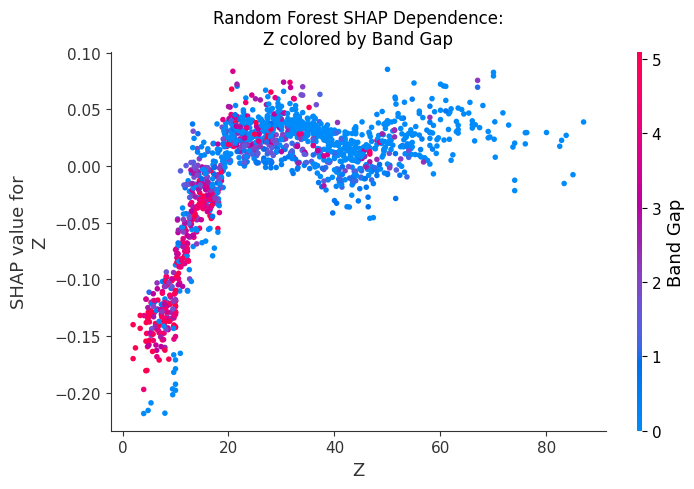

In [34]:

# SHAP DEPENDENCE PLOTS
# RANDOM FOREST
# Z dependence colored by Band Gap
plt.figure(figsize=(6,5))

shap.dependence_plot(
    "Z",
    shap_values_rf[:, :, 1],
    X_test,
    interaction_index="Band Gap",
    show=False
)

plt.title(
    "Random Forest SHAP Dependence:\nZ colored by Band Gap"
)

plt.tight_layout()
plt.show()


<Figure size 600x500 with 0 Axes>

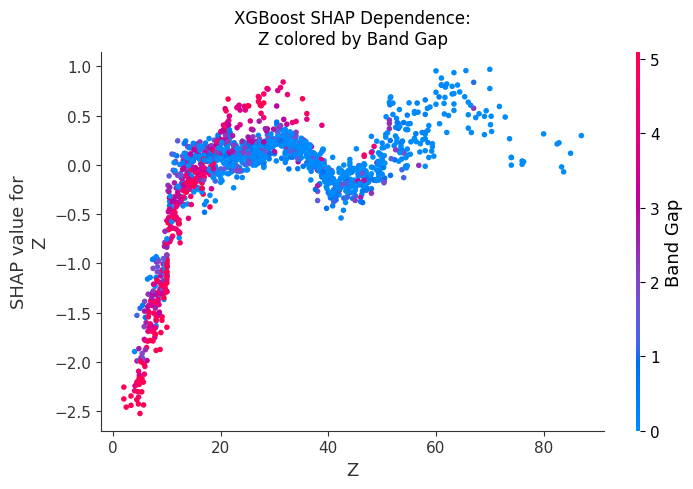

In [35]:
# XGBOOST
# Z dependence colored by Band Gap

plt.figure(figsize=(6,5))

shap.dependence_plot(
    "Z",
    shap_values_xgb,
    X_test,
    interaction_index="Band Gap",
    show=False
)

plt.title(
    "XGBoost SHAP Dependence:\nZ colored by Band Gap"
)

plt.tight_layout()
plt.show()

# PySR

In [37]:
# SYMBOLIC REGRESSION WITH PySR

# TOP FEATURES

TOP_FEATURES = [
    'Band Gap',
    'electronegativity',
    'Z',
    'spacegroup_number',
    'number of atoms',
    'a',
]

X_sr_train = X_train[TOP_FEATURES].copy()
X_sr_val   = X_val[TOP_FEATURES].copy()
X_sr_test  = X_test[TOP_FEATURES].copy()

y_sr_train = y_train.astype(float).values
y_sr_val   = y_val.astype(float).values
y_sr_test  = y_test.astype(float).values

print("PySR Training Shape :", X_sr_train.shape)
print("PySR Validation Shape:", X_sr_val.shape)
print("PySR Test Shape     :", X_sr_test.shape)


# BINARY CROSS-ENTROPY LOSS

BCE_LOSS_JULIA = """
function my_loss(prediction, target)
    p = 1.0f0 / (1.0f0 + exp(-prediction))
    p = clamp(p, 1.0f-7, 1.0f0 - 1.0f-7)
    return -(target * log(p) + (1.0f0 - target) * log(1.0f0 - p))
end
"""


# CONFIGURE PySR

pysr_model = PySRRegressor(

    # OPERATORS

    binary_operators=[
        "+",
        "-",
        "*",
        "/",
    ],

    unary_operators=[
        "square(x) = x^2",
        "cube(x) = x^3",
        "exp",
        "log_safe(x) = log(abs(x) + 1.0f-8)",
        "tanh",
    ],

    # REQUIRED FIX
    extra_sympy_mappings={
        "square": lambda x: x**2,
        "cube": lambda x: x**3,
        "log_safe": lambda x: sp.log(sp.Abs(x) + 1e-8),
    },

    # SEARCH COMPLEXITY

    maxsize=25,
    parsimony=0.003,

    complexity_of_operators={
        "square": 2,
        "cube": 3,
        "exp": 3,
        "log_safe": 3,
        "tanh": 3,
    },

    # LARGE SEARCH

    niterations=1500,

    populations=40,
    population_size=50,
    ncycles_per_iteration=500,

    # OBJECTIVE

    elementwise_loss=BCE_LOSS_JULIA,
    loss_scale="linear",

    # MODEL SELECTION

    model_selection="best",

    # FEATURE SELECTION

    select_k_features=6,

    # EARLY STOPPING

    early_stop_condition=(
        "f(loss, complexity) = (loss < 0.35) && (complexity < 18)"
    ),

    # PERFORMANCE

    parallelism="multithreading",

    # REPRODUCIBILITY

    random_state=42,

    # OUTPUT

    verbosity=1,
    progress=True,
    print_precision=5,
)

print("\nPySR model configured.")

PySR Training Shape : (6767, 6)
PySR Validation Shape: (1450, 6)
PySR Test Shape     : (1451, 6)

PySR model configured.


In [ ]:
# TRAIN PySR
print("\nTraining PySR model...")
print("This may take several minutes.\n")

pysr_model.fit(
    X_sr_train,
    y_sr_train,
    variable_names=[
        "Band_Gap",
        "electronegativity",
        "Z",
        "spacegroup_number",
        "number_of_atoms",
        "a",
    ]
)


Training PySR model...
This may take several minutes.



Using features ['Band_Gap' 'electronegativity' 'Z' 'spacegroup_number' 'number_of_atoms'
 'a']
INFO:pysr.sr:Using features ['Band_Gap' 'electronegativity' 'Z' 'spacegroup_number' 'number_of_atoms'
 'a']
Compiling Julia backend...
INFO:pysr.sr:Compiling Julia backend...
[ Info: Started!


Streaming output truncated to the last 5000 lines.
                           quare(a)) + 0.034756) / electronegativity)
21          4.385e-01  y = ((-0.50199 - (Band_Gap / (Z + -1.9716))) * log_safe(-0.004489 - (...
                           Band_Gap * cube(a)))) / electronegativity
23          4.378e-01  y = (-0.56361 - ((Band_Gap - 0.73247) / (Z + -1.9961))) * (log_safe((...
                           Band_Gap * cube(a)) + 0.0061556) / electronegativity)
25          4.375e-01  y = (-0.5916 - ((Band_Gap - 1.2011) / (Z + (0.044052 - electronegativ...
                           ity)))) * (log_safe((cube(a) * Band_Gap) - 0.007077) / electronegativ...
                           ity)
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 1.840e+03
Progress: 6

In [29]:
# Select topfeatures
TOP_FEATURES = [
    'Band Gap',
    'electronegativity',
    'Z',
    'spacegroup_number',
    'number of atoms',
    'a',
    'b',
    'c'
]

TARGET = 'label'

# Prepare dat for pysr
# Training data
X_sr_train = X_train[TOP_FEATURES].copy()
X_sr_val   = X_val[TOP_FEATURES].copy()
X_sr_test  = X_test[TOP_FEATURES].copy()

# Convert labels to float
y_sr_train = y_train.values.astype(float)
y_sr_val   = y_val.values.astype(float)
y_sr_test  = y_test.values.astype(float)

print("Train shape:", X_sr_train.shape)
print("Validation shape:", X_sr_val.shape)
print("Test shape:", X_sr_test.shape)

Train shape: (6767, 8)
Validation shape: (1450, 8)
Test shape: (1451, 8)


In [30]:
# Define Binary Classification Loss
BCE_LOSS = """
function my_loss(prediction, target)

    # Sigmoid transformation
    p = 1.0f0 / (1.0f0 + exp(-prediction))

    # Numerical stability
    p = clamp(p, 1.0f-7, 1.0f0 - 1.0f-7)

    # Binary cross entropy
    return -(target * log(p) + (1.0f0 - target) * log(1.0f0 - p))

end
"""

In [32]:
# CONFIGURE PySR MODEL

pysr_model = PySRRegressor(

    # Mathematical operators

    binary_operators=[
        "+",
        "-",
        "*",
        "/"
    ],

    unary_operators=[
        "square(x) = x^2",
        "cube(x) = x^3",
        "exp",
        "log(abs(x) + 1e-8)",
        "sqrt",
        "sin",
        "cos",
        "abs",
        "tanh"
    ],

    # Complexity control
       maxdepth=7,

    complexity_of_operators={
        "square": 2,
        "cube": 3,
        "exp": 3,
        "sqrt": 2,
        "sin": 2,
        "cos": 2,
        "abs": 1,
        "tanh": 2
    },

    parsimony=0.005,

    # Search configuration
    niterations=1000,
    populations=20,
    population_size=40,
    ncycles_per_iteration=300,

    # Binary classification loss
    elementwise_loss=BCE_LOSS,

    # Feature selection
    select_k_features=6,

    # Model selection
        model_selection="best",

    # Early stopping
    early_stop_condition="""
    stop_if(loss, complexity) = (loss < 0.45) && (complexity < 14)
    """,

    # Reproducibility
    random_state=42,

    # Output settings
    verbosity=1
)

print("PySR model configured successfully.")

PySR model configured successfully.


In [33]:

# TRAIN PySR MODEL
print("Training PySR model...")
print("This may take several minutes.\n")

pysr_model.fit(
    X_sr_train,
    y_sr_train,
    variable_names=TOP_FEATURES
)

print("\nTraining completed.")

Training PySR model...
This may take several minutes.



Using features ['Band_Gap' 'electronegativity' 'Z' 'spacegroup_number' 'number_of_atoms'
 'a']
INFO:pysr.sr:Using features ['Band_Gap' 'electronegativity' 'Z' 'spacegroup_number' 'number_of_atoms'
 'a']
Compiling Julia backend...
INFO:pysr.sr:Compiling Julia backend...


ValueError: Custom function square is not defined in `extra_sympy_mappings`. You can define it with, e.g., `model.set_params(extra_sympy_mappings={'inv': lambda x: 1/x})`, where `lambda x: 1/x` is a valid SymPy function defining the operator. You can also define these at initialization time.

In [32]:
FEATURES = [
    'number of atoms',
    'Band Gap',
    'a', 'b', 'c',
    'alpha', 'beta', 'gamma',
    'Z',
    'electronegativity'
]

TARGET = 'label'

df_model = df[FEATURES + [TARGET]].dropna().copy()

print(df_model.shape)

(9668, 11)


In [33]:
# Prepare data for PySR
X = df_model[FEATURES].values
y = df_model[TARGET].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9668, 10)
y shape: (9668,)


In [35]:
# Train PySR
model = PySRRegressor(
    niterations=1000,
    populations=15,
    model_selection="best",

    loss="logistic",   # for classification

    binary_operators=["+", "-", "*", "/"],
    unary_operators=["log", "sqrt"],

    maxsize=12,
    verbosity=1,
    random_state=42
)

model.fit(X, y)

Compiling Julia backend...
INFO:pysr.sr:Compiling Julia backend...


JuliaError: UndefVarError: `logistic` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Hint: a global variable of this name may be made accessible by importing LogExpFunctions in the current active module Main
Stacktrace:
 [1] top-level scope
   @ :0
 [2] eval
   @ ./boot.jl:430 [inlined]
 [3] eval
   @ ./Base.jl:130 [inlined]
 [4] pyjlmodule_seval(self::Module, expr::Py)
   @ PythonCall.JlWrap ~/.julia/packages/PythonCall/avYrV/src/JlWrap/module.jl:13
 [5] _pyjl_callmethod(f::Any, self_::Ptr{PythonCall.C.PyObject}, args_::Ptr{PythonCall.C.PyObject}, nargs::Int64)
   @ PythonCall.JlWrap ~/.julia/packages/PythonCall/avYrV/src/JlWrap/base.jl:67
 [6] _pyjl_callmethod(o::Ptr{PythonCall.C.PyObject}, args::Ptr{PythonCall.C.PyObject})
   @ PythonCall.JlWrap.Cjl ~/.julia/packages/PythonCall/avYrV/src/JlWrap/C.jl:63